In [1]:
# 在 Google Colab 里运行时：先把整个 kao 仓库克隆下来（数据都在里面），并装上中文字体；本地运行时这个格子什么也不做
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('大庆中考'):
    !git clone --depth 1 https://github.com/lin/kao.git /content/kao
    %cd /content/kao
    !apt-get -qq install -y fonts-noto-cjk > /dev/null
    import matplotlib.font_manager as fm
    for p in fm.findSystemFonts():
        if 'NotoSansCJK' in p: fm.fontManager.addfont(p)

# 2007 届绥化一中高三一班、三班前十名的中考成绩是怎么赋的？

两个班前面的同学，我们几乎没有中考成绩单，只有零碎的记忆和名次信息。这个 notebook 把赋分的办法写清楚，**而且所有的假设都集中在下面「可以修改的地方」那一个格子里**——
你觉得哪里不对，改那个格子，再点「全部运行」，后面的表、图和结论都会跟着重算。

| 班级 | 取谁 | 办法 |
|---|---|---|
| **高三一班** | 绥化市区的某几个名次（默认第 2 到第 11 名） | 市区第 1 名流失到大庆，第 2–11 名进了一班。直接取这些名次的分数 |
| **高三三班** | 外市县同学里，本县名次靠前、有可能进入班级前十的人，以及有确定分数的人 | 有确定分数的用确定分数；其余按「他在本县大约排第几」，**取绥化市区同名次的分数** |

「绥化市区各名次的分数」来自上一个 notebook（《2004年中考绥化市区前165名成绩单》）里用分布生成的成绩单，这里重新生成一遍，保证本 notebook 自成一体。

**不具名：** 三班的同学用去敏后的编号（三班-01…）表示，只写县市，不写姓名。

In [2]:
import math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'Heiti TC', 'SimHei', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 文件名在本项目里不同、内容相同的数据（已逐字节核对）
ALIAS = {'2007年高考理科一分一段表.csv': '2007年高考黑龙江省理科一分一段表（推断）.csv'}

def find(name):
    # 依次在 当前目录、content/kao 里找；找不到就在当前目录的所有子文件夹里递归找（kao 按文件夹分类存放）
    for base in [Path('.'), Path('content/kao')]:
        if (base / name).exists(): return base / name
    for nm in [name, ALIAS.get(name)]:
        if nm:
            hits = [p for p in Path('.').rglob(nm) if '.ipynb_checkpoints' not in str(p)]
            if hits: return hits[0]
    raise FileNotFoundError(name)

## ✏️ 可以修改的地方（只改下面这一个格子）

**① 高三一班**：取绥化市区的第几名到第几名（两端都包含）。

**② 绥化市区已知的名次分数**：`{名次: 分数}`。没写的名次，分数由分布推算。

**③ 高三三班外市县同学**：每人一行，写法二选一——

- `{'分数': 648}`：**确定的中考分数**，直接使用；
- `{'名次': (2, 5)}`：只知道大概名次时，写**本县名次区间**（最靠前, 最靠后）。程序取绥化市区这些名次分数的**平均**作为赋分，区间两端的分数作为不确定范围。
  知道确切名次就写成 `(3, 3)`；几个人分不出先后，就让他们**共用同一个区间**。

可选的两项：`'备注'`（只用来在表里说明，建议写上县市和名次信息）和 `'县内名次'`（有确定分数、又知道本县名次时填，用来做后面的「同名次同分数」检验）。
人员的编号对应去敏后的三班 CSV；县市从 CSV 里读，不用填。想**加人**就加一行，想**去掉**就删掉那一行。

**④ `TOP_N`**：看班级的前几名。

In [3]:
# ① 高三一班：取绥化市区的第几名到第几名
CLASS1_FROM, CLASS1_TO = 2, 11

# ② 绥化市区已知的名次分数（其余名次由分布推算）：第 1 名流失大庆 647，第 2 名 646，第 105 名 608
CITY_KNOWN = {1: 647, 2: 646, 105: 608}

# ③ 高三三班外市县同学：每人 {'分数': 确定分数} 或 {'名次': (最靠前, 最靠后)}
PEOPLE = {
    '三班-01': {'分数': 648, '县内名次': 3, '备注': '绥棱县第 3 名'},
    '三班-02': {'分数': 630, '县内名次': 13, '备注': '绥棱县第 13 名'},
    '三班-05': {'分数': 635, '备注': '北安市，已知分数'},
    '三班-06': {'名次': (2, 5),   '备注': '海伦市，前几名'},
    '三班-07': {'名次': (3, 3),   '备注': '望奎县第 3 名'},
    '三班-10': {'名次': (6, 8),   '备注': '望奎县第六七八名之一，三人共用区间'},
    '三班-11': {'名次': (6, 8),   '备注': '望奎县第六七八名之一，三人共用区间'},
    '三班-15': {'名次': (6, 8),   '备注': '望奎县第六七八名之一，三人共用区间'},
    '三班-33': {'名次': (2, 5),   '备注': '北安市，前几名'},
    '三班-35': {'名次': (10, 10), '备注': '绥棱县第 10 名'},
    '三班-48': {'名次': (5, 5),   '备注': '望奎县第 5 名'},
    '三班-60': {'名次': (7, 10),  '备注': '青冈县，前十名靠后'},
}

# ④ 看班级的前几名
TOP_N = 10

## 0 读数据：三班的同学

In [4]:
c3 = pd.read_csv(find('2004年中考和2007年高考绥化一中高三三班.csv'), encoding='utf-8-sig')   # 已去敏：只有编号，没有姓名
missing = [k for k in PEOPLE if k not in set(c3['编号'])]
assert not missing, f'这些编号在 CSV 里找不到：{missing}'
out_town = c3[c3['编号'].isin(PEOPLE)].copy()
print(f'三班共 {len(c3)} 人（已去敏）；本 notebook 估算其中 {len(out_town)} 人（外市县：本县名次靠前或有确定分数）')

三班共 66 人（已去敏）；本 notebook 估算其中 12 人（外市县：本县名次靠前或有确定分数）


## 1 绥化市区各名次的分数

用前两个 notebook 的分布生成：629 分以下 N(533.5, 36.3²)、629 分及以上 N(579, 19²)；第 r 名的分数是「≥x 的人数 = r − 0.5」的解，取整。
`CITY_KNOWN` 里已知的名次直接用已知分数；其余名次保持单调（不会高于前面已知名次、不会低于后面已知名次）。

In [5]:
N = 4923
(x1, n1), (x2, n2) = (571, 742), (600, 165)            # 绥化一中录取线 571/742 人；600 分以上 165 人
z1, z2 = norm.isf(n1 / N), norm.isf(n2 / N)
SIG_A = (x2 - x1) / (z2 - z1); MU_A = x1 - SIG_A * z1   # N(533.5, 36.3²)
SIG_B, X0 = 19, 629
MU_B = X0 - SIG_B * (X0 - MU_A) / SIG_A                  # 629 分及以上 N(579, 19²)，接缝处人数连续

def count_ge(x):
    return N * norm.sf((x - MU_A) / SIG_A) if x <= X0 else N * norm.sf((x - MU_B) / SIG_B)

MAX_RANK = 300
city = np.array([round(brentq(lambda x: count_ge(x) - (r - 0.5), 500, 700)) for r in range(1, MAX_RANK + 1)], dtype=float)
for r, s in CITY_KNOWN.items(): city[r - 1] = s                       # 已知的名次分数
pins = sorted(CITY_KNOWN)
for i in range(MAX_RANK):                                              # 保持单调：夹在相邻两个已知名次之间
    r = i + 1
    if r in CITY_KNOWN: continue
    above = [p for p in pins if p < r]; below = [p for p in pins if p > r]
    hi = CITY_KNOWN[above[-1]] if above else np.inf
    lo = CITY_KNOWN[below[0]] if below else -np.inf
    city[i] = min(max(city[i], lo), hi)
assert (np.diff(city) <= 0).all(), '已知名次分数与分布矛盾，请检查 CITY_KNOWN'
city_score = lambda r: int(city[int(r) - 1])
pd.DataFrame({'市区名次': range(1, 31), '分数': city[:30].astype(int)}).set_index('市区名次').T

市区名次,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
分数,647,646,641,640,638,637,636,635,635,634,...,629,629,628,628,627,627,626,626,625,625


## 2 高三一班：绥化市区的若干名次（默认第 2–11 名，可在上面修改）

In [6]:
class1 = pd.DataFrame({'市区名次': range(CLASS1_FROM, CLASS1_TO + 1), '中考分数': [city_score(r) for r in range(CLASS1_FROM, CLASS1_TO + 1)]})
print(f'高三一班（市区第 {CLASS1_FROM}–{CLASS1_TO} 名，共 {len(class1)} 个名次）：', class1['中考分数'].tolist(), '；平均', round(class1['中考分数'].mean(), 1))
class1.set_index('市区名次').T

高三一班（市区第 2–11 名，共 10 个名次）： [646, 641, 640, 638, 637, 636, 635, 635, 634, 633] ；平均 637.5


市区名次,2,3,4,5,6,7,8,9,10,11
中考分数,646,641,640,638,637,636,635,635,634,633


## 3 高三三班外市县：确定的和按名次赋的

每个人的信息来自回忆与当年的资料，分三种：

- **确定的分数**：直接用；
- **确切名次**（如「望奎第 3」）：取绥化市区同名次的分数；
- **只知道大概**（如「前几」「前十名靠后」）：给一个**名次区间**，取区间内各名次分数的**平均**，同时记下区间两端的分数作为不确定范围。

几个人分不出先后（如「望奎第六七八名」），就让他们**共用**同一个区间，不人为排先后。

In [7]:
def assign(info):
    if ('分数' in info) == ('名次' in info):
        raise ValueError(f'每人要写且只写「分数」或「名次」之一：{info}')
    if '分数' in info:
        s = info['分数']; return s, s, s
    a, b = info['名次']
    assert 1 <= a <= b <= MAX_RANK, f'名次区间不合法：{info}'
    sc = [city_score(r) for r in range(a, b + 1)]
    return round(float(np.mean(sc)), 1), max(sc), min(sc)                    # 平均、最高、最低

def describe(info):                                                          # 「输入」列：写进去的是分数还是名次
    if '分数' in info: return f"分数 {info['分数']}"
    a, b = info['名次']; return f'名次 {a}' if a == b else f'名次 {a}–{b}'

rows = []
for _, r in out_town.iterrows():
    info = PEOPLE[r['编号']]; s, hi, lo = assign(info)
    rows.append({'编号': r['编号'], '县市': r['初中生源地'], '输入': describe(info), '备注': info.get('备注', ''), '赋分': s, '最高': hi, '最低': lo,
                 '已知': '分数' in info})
c3_out = pd.DataFrame(rows).sort_values(['赋分', '编号'], ascending=[False, True]).reset_index(drop=True)
c3_out.index += 1
print(f'参与估算的 {len(c3_out)} 人；前 {min(TOP_N, len(c3_out))} 位是班级前十名的候选')
c3_out[['编号', '县市', '输入', '备注', '赋分', '最低', '最高']]

参与估算的 12 人；前 10 位是班级前十名的候选


,编号,县市,输入,备注,赋分,最低,最高
1,三班-01,绥棱县,分数 648,绥棱县第 3 名,648.0,648,648
2,三班-06,海伦市,名次 2–5,海伦市，前几名,641.2,638,646
3,三班-33,北安市,名次 2–5,北安市，前几名,641.2,638,646
4,三班-07,望奎县,名次 3,望奎县第 3 名,641.0,641,641
5,三班-48,望奎县,名次 5,望奎县第 5 名,638.0,638,638
6,三班-10,望奎县,名次 6–8,望奎县第六七八名之一，三人共用区间,636.0,635,637
7,三班-11,望奎县,名次 6–8,望奎县第六七八名之一，三人共用区间,636.0,635,637
8,三班-15,望奎县,名次 6–8,望奎县第六七八名之一，三人共用区间,636.0,635,637
9,三班-05,北安市,分数 635,北安市，已知分数,635.0,635,635
10,三班-60,青冈县,名次 7–10,青冈县，前十名靠后,635.0,634,636


### 一个检查：「同名次同分数」靠谱吗？

「县内第 k 名 ≈ 绥化市区第 k 名的分数」隐含「县里的第 k 名和市区的第 k 名分数差不多」。凡是**同时知道本县名次和分数**的人（在 `PEOPLE` 里同时填了 `分数` 和 `县内名次`），都可以拿来做个粗略检验：

In [8]:
chk = [{'编号': k, '县内名次': v['县内名次'], '实际分数': v['分数'], '市区同名次分数': city_score(v['县内名次'])}
       for k, v in PEOPLE.items() if '分数' in v and '县内名次' in v]
if chk:
    checks = pd.DataFrame(chk).merge(c3[['编号', '初中生源地']], on='编号').rename(columns={'初中生源地': '县市'})
    checks['差（县 − 市区）'] = checks['实际分数'] - checks['市区同名次分数']
    display(checks.set_index('编号'))
else:
    print('PEOPLE 里没有同时填了「分数」和「县内名次」的人，跳过检验')

,县内名次,实际分数,市区同名次分数,县市,差（县 − 市区）
编号,,,,,
三班-01,3,648,641,绥棱县,7
三班-02,13,630,632,绥棱县,-2


默认参数下有两个点：本县第 3 名比市区第 3 名**高 7 分**，本县第 13 名比市区第 13 名**低 2 分**，一正一负，样本只有两个，**看不出县里的同名次整体是偏高还是偏低**；它们只说明对某一个具体的人，误差可能有好几分，甚至更多——这就是表里给每个人保留「最高/最低」范围的原因。

## 4 前十名：两个班放在一起比

In [9]:
top = c3_out.head(TOP_N)
k = min(len(class1), len(top), TOP_N)
cmp = pd.DataFrame({'名次': range(1, k + 1),
                    f'一班（市区第 {CLASS1_FROM}–{CLASS1_TO} 名）': class1['中考分数'].to_list()[:k],
                    '三班外市县': top['赋分'].to_list()[:k]}).set_index('名次')
m1, m3 = class1['中考分数'].head(TOP_N).mean(), top['赋分'].mean()
print(f'一班前 {min(TOP_N, len(class1))} 名平均 {m1:.1f}（{class1["中考分数"].head(TOP_N).max()} 到 {class1["中考分数"].head(TOP_N).min()}）；'
      f'三班外市县前 {len(top)} 名平均 {m3:.1f}（{top["赋分"].max():.0f} 到 {top["赋分"].min():.0f}）；差（一班 − 三班）{m1 - m3:+.1f} 分')
cmp.T

一班前 10 名平均 637.5（646 到 633）；三班外市县前 10 名平均 638.7（648 到 635）；差（一班 − 三班）-1.2 分


名次,1,2,3,4,5,6,7,8,9,10
一班（市区第 2–11 名）,646.0,641.0,640.0,638.0,637.0,636.0,635.0,635.0,634.0,633.0
三班外市县,648.0,641.2,641.2,641.0,638.0,636.0,636.0,636.0,635.0,635.0


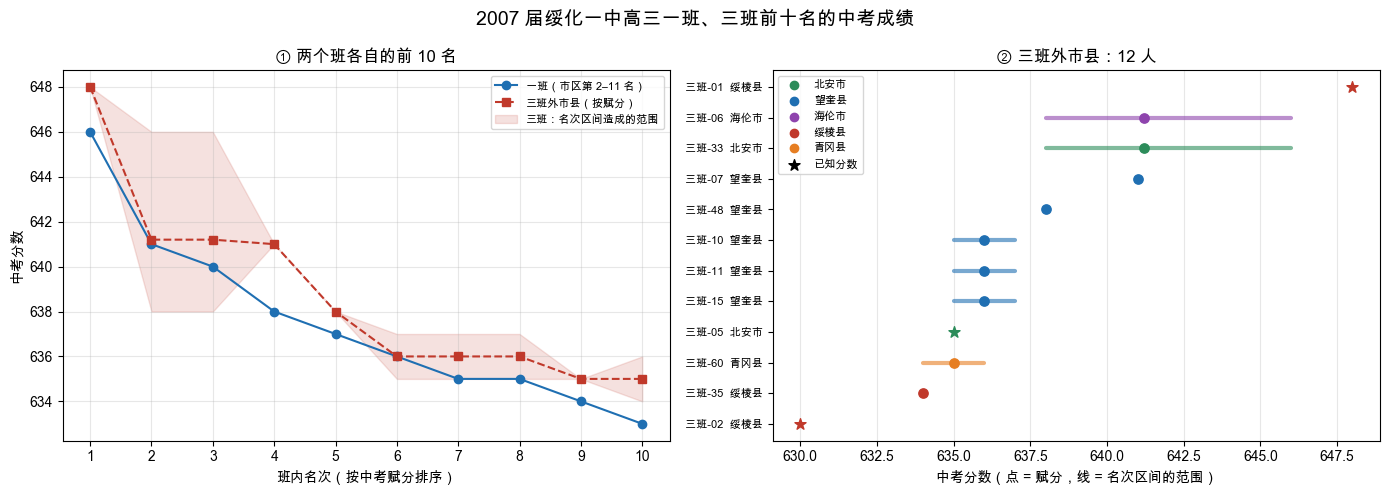

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
BLUE, RED, GREY = '#1f6fb2', '#c0392b', '#7f8c8d'
COL = {'绥棱县': '#c0392b', '望奎县': '#1f6fb2', '北安市': '#2c8c5a', '海伦市': '#8e44ad', '青冈县': '#e67e22', '绥化市区': '#7f8c8d'}

# ① 前几名：一班 vs 三班外市县
a = ax[0]
c1 = class1['中考分数'].head(TOP_N)
a.plot(range(1, len(c1) + 1), c1, 'o-', color=BLUE, label=f'一班（市区第 {CLASS1_FROM}–{CLASS1_TO} 名）')
x3 = range(1, len(top) + 1)
a.plot(x3, top['赋分'].to_numpy(), 's--', color=RED, label='三班外市县（按赋分）')
a.fill_between(x3, top['最低'].to_numpy(), top['最高'].to_numpy(), color=RED, alpha=.15, label='三班：名次区间造成的范围')
a.set_xlabel('班内名次（按中考赋分排序）'); a.set_ylabel('中考分数'); a.set_xticks(range(1, max(len(c1), len(top)) + 1))
a.set_title(f'① 两个班各自的前 {TOP_N} 名'); a.legend(fontsize=8); a.grid(alpha=.3)

# ② 三班外市县逐人：范围条
a = ax[1]
d = c3_out.iloc[::-1]
for i, (_, r) in enumerate(d.iterrows()):
    col = COL.get(r['县市'], '#555')
    a.plot([r['最低'], r['最高']], [i, i], color=col, lw=3, alpha=.6, solid_capstyle='round')
    a.scatter([r['赋分']], [i], s=70 if r['已知'] else 45, marker='*' if r['已知'] else 'o', color=col, zorder=3)
a.set_yticks(range(len(d))); a.set_yticklabels([f'{e}  {c}' for e, c in zip(d['编号'], d['县市'])], fontsize=8)
for t_ in sorted(set(d['县市'])): a.scatter([], [], color=COL.get(t_, '#555'), label=t_)
a.scatter([], [], marker='*', s=70, color='k', label='已知分数'); a.legend(fontsize=8, loc='upper left')
a.set_xlabel('中考分数（点 = 赋分，线 = 名次区间的范围）'); a.set_title(f'② 三班外市县：{len(c3_out)} 人'); a.grid(alpha=.3, axis='x')
fig.suptitle('2007 届绥化一中高三一班、三班前十名的中考成绩', fontsize=14)
fig.tight_layout(); fig.savefig('2007届绥化一中高三一班和高三三班前十名中考成绩.png', dpi=150); plt.show()

## 5 把它们画进 Q-Q 图

前面的《大庆 / 哈尔滨 / 鹤岗 Q-Q 曲线》三个 notebook 画的是同一张图的不同部分。这里把它们和上面两个班放在一起，就是《绥化一中高三三班中考和高考分位数对应图》里的那张 Q-Q 图：

- **红线**：大庆市区应届的「中考分 → 预测高考分」曲线（实线有锚点支持，623–625 分一小段是外推，画虚线）；
- **蓝点**：哈尔滨市区应届生（按人数比例换算到大庆的中考位置，已核实的应届生）；
- **绿点**：鹤岗市区应届生（假设分数分布同绥化，6400 名市区考生，一中、三中理科应届生）；
- **棕色菱形**：高三一班前五名——中考取上面的市区第 2–6 名，高考取已知的前五个高考分；
- **紫色菱形**：高三三班外市县前十名——中考取上面的赋分（从高到低），高考取三班外市县同学的高考分从高到低（实心 = 前五名）。

**读法：**每个点是 Q-Q 点——「第 N 名的中考分」对「第 N 名的高考分」，两个分数各自单独排序，**不对应具体的人**。点在红线下面，说明该班同名次的高考分比大庆市区应届的同名次预测更低。

In [11]:
# ---- 红线：大庆市区应届 Q-Q 曲线（做法见《大庆市区应届 Q-Q 曲线的来源》）----
roster = pd.read_csv(find('2004年大庆中考录取总表.csv'), encoding='utf-8-sig')
roster['文体'] = pd.to_numeric(roster['文化课+体育成绩'])
city_rank = lambda z: int((roster['文体'] > z).sum() + 1)                    # 中考分 → 大庆市区位次
ys = pd.read_csv(find('2007年高考理科一分一段表.csv'), encoding='utf-8-sig').sort_values('累计人数')
score_of_m = lambda m: float(np.interp(m, ys['累计人数'], ys['分数']))        # 全省位次 → 高考分
ANCH = [(2, 16.4), (12, 84), (30, 225), (56, 339), (87, 510), (129, 693), (177, 942), (234, 1227), (274, 1598)]

def m_of_n(n):
    if n > ANCH[-1][0]: return None                                          # 最后一个锚点之后：外推，下面单独处理
    i = 0
    while i < len(ANCH) - 2 and n > ANCH[i + 1][0]: i += 1
    (n0, m0), (n1, m1) = ANCH[i], ANCH[i + 1]
    w = (math.log(n) - math.log(n0)) / (math.log(n1) - math.log(n0))
    return math.exp(math.log(m0) + w * (math.log(m1) - math.log(m0)))

red_tab = pd.DataFrame({'z': range(623, 664)})
red_tab['g'] = [score_of_m(m_of_n(city_rank(z))) if m_of_n(city_rank(z)) is not None else np.nan for z in red_tab['z']]
# 623–625 分在最后一个锚点之后：沿用旧曲线 × 固定比例的外推（见《大庆市区应届 Q-Q 曲线的来源》），这里取与页面一致的三个值
for z_, g_ in {625: 649.3, 624: 646.7, 623: 645.4}.items(): red_tab.loc[red_tab['z'] == z_, 'g'] = g_
red = lambda z: float(np.interp(z, red_tab['z'], red_tab['g']))

# ---- 哈尔滨：已核实的市区应届生（按人数比例换算到大庆位置）----
hrb = pd.read_csv(find('2004年哈尔滨中考换算大庆等效中考（Q-Q位置，67个）.csv'), encoding='utf-8-sig')
hrb.columns = ['N', 'r', 'z', 'p_old', 'pc', 'g', 'd', 'inc']
hrb = hrb[hrb['N'] >= 2]                                                    # 第 1 个位置（718 分）是异常值，不画

# ---- 鹤岗：假设市区 HG_TOTAL 人、分数分布同绥化 ----
HG_TOTAL = 6400
hg = pd.read_csv(find('2004年中考和2007年高考鹤岗市.csv'), encoding='utf-8-sig')
hg = hg[hg['毕业高中'].isin(['鹤岗市第一中学', '鹤岗市第三中学']) & (hg['科类'] == '理科')]
g_hg = np.sort(hg['2007高考成绩'].to_numpy(dtype=float))[::-1]               # 第 N 高的高考分
q0 = norm.sf((X0 - MU_A) / SIG_A)
qs = (np.arange(1, len(g_hg) + 1) - .5) / HG_TOTAL
z_hg = np.array([MU_B + SIG_B * norm.isf(q) if q < q0 else MU_A + SIG_A * norm.isf(q) for q in qs])
keep_hg = (np.arange(1, len(g_hg) + 1) >= 2) & (z_hg >= 620)                # 第 1 位（703）是孤立值；中考 620 分以下不画

# ---- 一班前五：中考取上面的名次分数，高考取已知的高考分 ----
c1 = pd.read_csv(find('2004年中考和2007年高考绥化一中高三一班.csv'), encoding='utf-8-sig')
g1 = np.sort(pd.to_numeric(c1.loc[c1['高考分数性质'] == '已知', '高考分数']).to_numpy())[::-1][:5]
x1 = class1['中考分数'].to_numpy()[:len(g1)]

# ---- 三班外市县前十：中考取上面的赋分，高考取三班外市县同学的高考分（从高到低）----
g3_all = pd.to_numeric(c3.loc[c3['初中生源地'] != '绥化市区', '高考分数'], errors='coerce').dropna().to_numpy()
y3 = np.sort(g3_all)[::-1][:TOP_N]
x3 = top['赋分'].to_numpy()[:len(y3)]
print(f'哈尔滨 {len(hrb)} 个位置；鹤岗 {int(keep_hg.sum())} 个位置；一班 {len(g1)} 个点；三班 {len(y3)} 个点')

哈尔滨 66 个位置；鹤岗 54 个位置；一班 5 个点；三班 10 个点


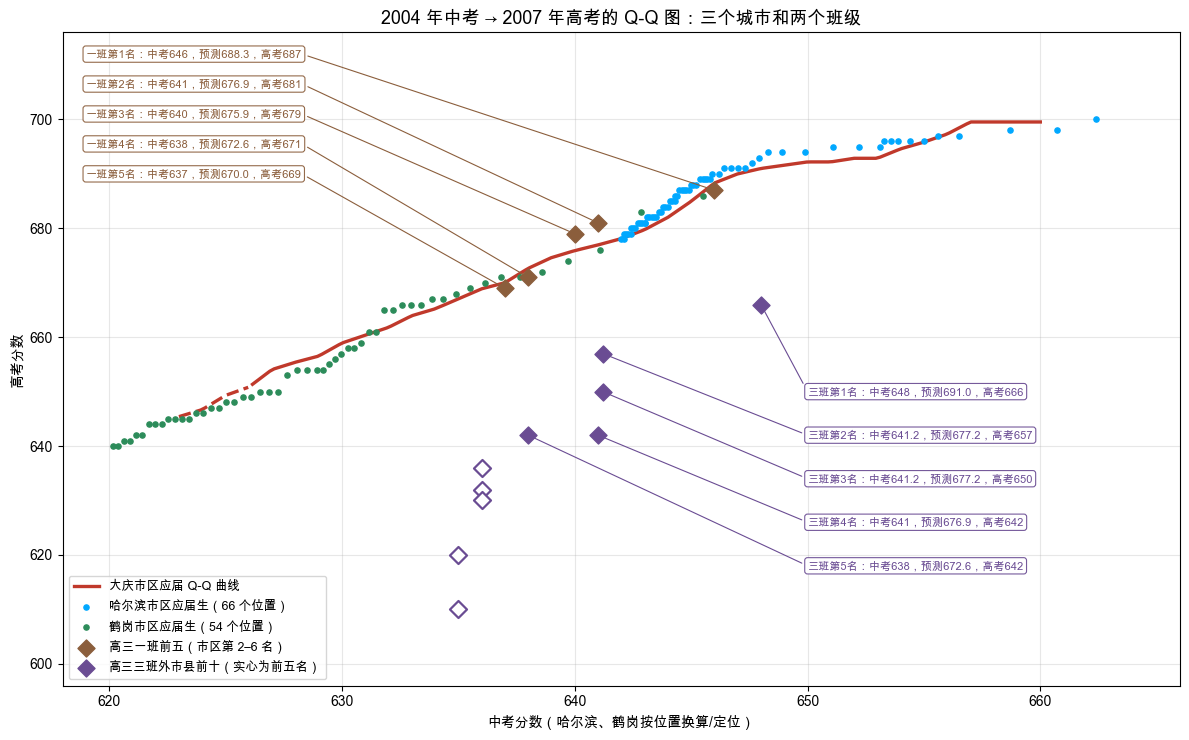

In [12]:
VIOLET, BROWN, SKY, MOSS, RED = '#6a4c93', '#8b5e3c', '#00a8ff', '#2c8c5a', '#c0392b'
fig, a = plt.subplots(figsize=(12, 7.5))
zr = np.linspace(623, 660, 200); z_solid = zr[zr >= 626]; z_dash = zr[zr <= 626]
a.plot(z_solid, [red(z) for z in z_solid], color=RED, lw=2.4, label='大庆市区应届 Q-Q 曲线')
a.plot(z_dash, [red(z) for z in z_dash], color=RED, lw=2.4, ls='--')
a.scatter(hrb['z'], hrb['g'], s=14, color=SKY, zorder=3, label=f'哈尔滨市区应届生（{len(hrb)} 个位置）')
a.scatter(z_hg[keep_hg], g_hg[keep_hg], s=14, color=MOSS, zorder=3, label=f'鹤岗市区应届生（{int(keep_hg.sum())} 个位置）')
a.scatter(x1, g1, marker='D', s=75, color=BROWN, zorder=4, label=f'高三一班前五（市区第 {CLASS1_FROM}–{CLASS1_FROM + len(g1) - 1} 名）')
a.scatter(x3[:5], y3[:5], marker='D', s=75, color=VIOLET, zorder=4, label='高三三班外市县前十（实心为前五名）')
a.scatter(x3[5:], y3[5:], marker='D', s=75, facecolor='white', edgecolor=VIOLET, lw=1.6, zorder=4)
# 前五名的标注：一班在左上方，三班在右下方；每条标注写「班级第 N 名：中考、红线预测、高考」
fmt = lambda v: f'{v:.1f}'.rstrip('0').rstrip('.')
def label_points(xs, ys, name, color, x_text, y_texts, ha, relpos):
    for i, (xx, yy, ty) in enumerate(zip(xs[:5], ys[:5], y_texts)):
        a.annotate(f'{name}第{i + 1}名：中考{fmt(xx)}，预测{red(xx):.1f}，高考{fmt(yy)}', xy=(xx, yy), xytext=(x_text, ty),
                   fontsize=8, color=color, ha=ha, va='center', zorder=5,
                   bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=color, lw=.8, alpha=.92),
                   arrowprops=dict(arrowstyle='-', color=color, lw=.8, shrinkB=4, relpos=relpos))
label_points(x1, g1, '一班', BROWN, 619, [712, 706.5, 701, 695.5, 690], 'left', (1, 0.5))          # 左上方
label_points(x3, y3, '三班', VIOLET, 650, [650, 642, 634, 626, 618], 'left', (0, 0.5))              # 右下方
a.set_xlabel('中考分数（哈尔滨、鹤岗按位置换算/定位）'); a.set_ylabel('高考分数')
a.set_xlim(618, 666); a.set_ylim(596, 716); a.grid(alpha=.3); a.legend(fontsize=9, loc='lower left')
a.set_title('2004 年中考 → 2007 年高考的 Q-Q 图：三个城市和两个班级', fontsize=13)
fig.tight_layout(); fig.savefig('2007届绥化一中高三一班和高三三班在Q-Q图中的位置.png', dpi=150); plt.show()

In [13]:
# 两个班的点相对红线高低：高考 − 红线在该中考分的预测
def gap(x, y): return [round(float(yy - red(xx)), 1) for xx, yy in zip(x, y)]
t1 = pd.DataFrame({'中考': x1, '高考': g1, '红线预测': [round(red(v), 1) for v in x1], '差': gap(x1, g1)}, index=range(1, len(g1) + 1))
t3 = pd.DataFrame({'中考': x3.round(1), '高考': y3, '红线预测': [round(red(v), 1) for v in x3], '差': gap(x3, y3)}, index=range(1, len(y3) + 1))
print(f'一班前 {len(g1)} 名：平均差 {np.mean(t1["差"]):+.1f}；三班外市县前 {len(y3)} 名：平均差 {np.mean(t3["差"]):+.1f}（前五名 {np.mean(t3["差"][:5]):+.1f}，后五名 {np.mean(t3["差"][5:]):+.1f}）')
print(f'哈尔滨 {np.mean(hrb["g"] - hrb["pc"]):+.1f}；鹤岗 {np.mean([g - red(z) for g, z, k in zip(g_hg, z_hg, keep_hg) if k and z >= 623]):+.1f}')
display(t1.T); display(t3.T)

一班前 5 名：平均差 +0.7；三班外市县前 10 名：平均差 -35.1（前五名 -27.6，后五名 -42.5）
哈尔滨 +1.6；鹤岗 -0.6


,1,2,3,4,5
中考,646.0,641.0,640.0,638.0,637.0
高考,687.0,681.0,679.0,671.0,669.0
红线预测,688.3,676.9,675.9,672.6,670.0
差,-1.3,4.1,3.1,-1.6,-1.0


,1,2,3,4,5,6,7,8,9,10
中考,648.0,641.2,641.2,641.0,638.0,636.0,636.0,636.0,635.0,635.0
高考,666.0,657.0,650.0,642.0,642.0,636.0,632.0,630.0,620.0,610.0
红线预测,691.0,677.2,677.2,676.9,672.6,668.9,668.9,668.9,667.0,667.0
差,-25.0,-20.2,-27.2,-34.9,-30.6,-32.9,-36.9,-38.9,-47.0,-57.0


## 6 结论与边界（按默认参数）

1. **一班前十名**：就是绥化市区第 2–11 名，中考 646 到 633，平均 637.5。这是**分班模型**的假设——市区第 1 名流失到大庆、第 2–11 名全进一班。
2. **三班外市县前十名**：列本县名次靠前、有可能进入前十的人，以及有确定分数的人，共 12 人，取其中前十，648 到 635，平均 638.7（确定分数为 630 的那位排第 12，不在前十）。有确定分数的 3 人（648、635、630），其余按县内名次取市区同名次的分数；名次不确定的（「前几」等）给出范围。
3. **能说**：按这套赋分，两个班的前十名几乎一样，三班外市县前十还略高 1.2 分。
   **但要注意这在很大程度上是赋分办法决定的**：「县内第 k 名取市区第 k 名的分数」，而三班外市县的名次大多落在前十几名，分数自然和一班的市区第 2–11 名接近。真正来自数据的只有三个确定分数（648、635、630）。
4. **Q-Q 图上的位置（第 5 节）**：一班前五的点基本落在红线上（高考 − 红线平均 +0.7）；三班外市县前十的点全都在红线下面，平均低约 35 分（前五名约 −28，后五名约 −43）。
   对照的哈尔滨（平均 +1.6）、鹤岗（平均 −0.6）也都在红线附近。所以在这张图上，**一班、哈尔滨、鹤岗的点都符合大庆曲线，三班外市县是明显的例外**。
5. **不能说**：
   - 三班外市县的点比一班低这么多，**不能直接归因于高考发挥**：中考一侧是赋分（取市区同名次的分数），如果县里同名次的真实分数低于市区同名次，这些点会整体向左移，缺口会小一些；
     而用来检验这个办法的点只有两个（本县第 3 名高 7 分、第 13 名低 2 分），看不出是偏高还是偏低。另外中考一侧的 11 人和高考一侧的外市县同学名单并不完全相同，且只有 10 个点，样本很小；
   - 「县内第 k 名 = 市区第 k 名」只是一个约定；检验只有两个点（一个高 7 分、一个低 2 分），看不出整体偏向，个别人的误差可能达好几分；
   - 县与县（望奎、绥棱、北安、海伦、青冈）、县与市区的考生规模不同，同一个名次背后的分数分布本来就不完全一样；
   - 「前几」这类回忆只给了区间，本 notebook 取区间平均，没有额外的信息来区分区间内谁高谁低；
   - 三班另有一批市区同学，这里没有讨论，他们的名次比这里的外市县靠后得多。

改了参数之后，上面第 4 节会打印新的平均分和差，请以那里的输出为准，本节文字对应默认参数。